<a href="https://colab.research.google.com/github/BunyanutIn/BSC_DPDM2025/blob/main/DecisionTreeRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 2
[CCA](https://https://colab.research.google.com/drive/1wf3E5hS0J-2UvFFgpe55wzEq-moumpka?usp=sharing)
</br>
[TransformedTargetRegressor](https://https://colab.research.google.com/drive/1hRtgWbJTP_9erBb45ZKnQIRV8wlderxY)
</br>
[LSTM](https://https://drive.google.com/file/d/1PshafWrGYw5WIS9ynfGrHnDEapBREufP/view?usp=sharing)

</br>

**สมาชิก** </br>
1. นางสาวกรวลัย แสนสิงห์            663020276-9</br>
2. นางสาวศศิกานต์ ทิพย์สูงเนิน     663020297-1</br>
3. นางสาวบุณยนุช อินทวงษ์          663020582-2</br>
4. นายวชิรวิทย์ มูลละออง              663020584-8</br>


# DecisionTreeRegressor — Rainfall Forecasting (Cluster 6)
## Pipeline เหมือน LSTM_V23_11 ทุก Cell

| รายการ | ค่า |
|---|---|
| Model | `DecisionTreeRegressor` (scikit-learn) |
| Cluster | 6 — สถานี: 351201, 376201, 376202, 376401, 378201, 379201, 379401 |
| window_size | 24 เดือน |
| horizon | 12 เดือน |
| Features | RMM_AMPLITUDE, BSISO1, DMI, SWM, NE, ONI_lag1, Month_sin, Month_cos + rainfall |
| Scaler | `StandardScaler().fit_transform()` บน dataset เดิม (เหมือน Cell 22 LSTM) |
| Lag | apply ก่อน normalize (เหมือน Cell 9 LSTM) |
| Folds | Fold1 Test: 2019-01 → 2021-12 &nbsp; Fold2 Test: 2022-01 → 2024-12 |

> **หมายเหตุ:** ไฟล์ข้อมูลต้องอยู่ใน `base_path` เดียวกับ notebook  
> ชื่อไฟล์: `X_variable(Index)_operation_v4.csv`, `Y_variable(Rainfall).csv`,  
> `Node_table_TMD.csv`, `lookup_table_reanalysis_v5.csv`


## Cell 1 — Libraries

In [ ]:
import os
import copy
import random
import pickle
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2 — Hyperparameters (เหมือน Cell 5 ของ LSTM)

In [ ]:
# ── เหมือน LSTM ──────────────────────────────────────────────
algo        = 'DecisionTree_V1'
window_size = 24    # Window size
horizon     = 12    # Prediction horizon
cluster     = 6     # HII station cluster
k_fold_num  = 2

# ── Decision Tree hyperparameters ────────────────────────────────────────────
max_depth         = None
min_samples_split = 2
min_samples_leaf  = 1
random_state      = 0


# Load Data

## Cell 3 — กำหนด Path ไฟล์

In [ ]:
base_path = '/content/drive/MyDrive/KKU_Workshop3'   # ← เปลี่ยนตรงนี้ถ้าใช้ Colab

X_csv       = os.path.join(base_path, 'X_variable(Index)_operation_v4.csv')
Y_csv       = os.path.join(base_path, 'Y_variable(Rainfall).csv')
node_csv    = os.path.join(base_path, 'Node_table_TMD.csv')
feature_csv = os.path.join(base_path, 'lookup_table_reanalysis_v5.csv')

## Cell 4 — โหลดข้อมูลดิบ (= LSTM Cell 7+8)

In [ ]:
# LSTM Cell 7
X_index    = pd.read_csv(X_csv)
Y_rainfall = pd.read_csv(Y_csv)
node       = pd.read_csv(node_csv)
feature    = pd.read_csv(feature_csv, header='infer')

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')   # format ให้ตรงกับ Y

# LSTM Cell 8
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

num_feature = len(feature[feature['Cluster'] == cluster])

print('X_index shape  :', X_index.shape)
print('Y_rainfall shape:', Y_rainfall.shape)
print('X columns      :', list(X_index.columns))


X_index shape  : (541, 11)
Y_rainfall shape: (771, 133)
X columns      : ['DATE', 'MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI', 'ONI', 'PDO', 'SWM', 'NE']


# Feature Engineering

## Cell 5 — สร้าง Lag Features (= LSTM Cell 9)

> ⚠️ **Critical:** Lag ต้องทำ**ก่อน** normalization — เหมือน LSTM ที่ apply lag ใน Cell 9  
> แล้วค่อย normalize ใน Cell 22


In [ ]:
# LSTM Cell 9 — คัดลอก logic ทุกบรรทัด
def apply_time_lag(df, column_name, lag):
    new_column_name = f"{column_name}_lag{lag}"
    df[new_column_name] = df[column_name].shift(lag)
    return df

time_lags = {
    'MEIV2':         [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE':         [1],
    'PDO':           [1, 2],
    'ONI':           [1, 2],
    'DMI':           [1, 2],
    'BSISO1':        [1],
    'BSISO1-Phase':  [1],
    'SWM':           [1],
}

for column, lags in time_lags.items():
    if column in X_index.columns:
        for lag_item in lags:
            X_index = apply_time_lag(X_index, column, lag_item)
    else:
        print(f"Warning: '{column}' not found — skipping.")

print('X shape after lag:', X_index.shape)
# expect (541, 25) = 1 DATE + 10 original + 14 lag columns


X shape after lag: (541, 25)


## Cell 6 — Data Cleansing ฝน (= LSTM Cell 11)

In [ ]:
# LSTM Cell 11 — คัดลอก logic ทุกบรรทัด
HQ_date_get_month_df = Y_rainfall.copy()
Y_rainfall_clean     = Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    HQ_data    = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]
    av_r       = HQ_data.iloc[:, 1:].median()
    month_dict = {'MONTH': month}
    month_dict.update(av_r)
    month_avg_list.append(month_dict)
HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if np.isnan(Y_rainfall_clean.iloc[j, i]):
            Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[
                pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j] - 1, i
            ]

print('Missing values after cleansing:', Y_rainfall_clean.isnull().sum().sum())


Missing values after cleansing: 0


## Cell 7 — Filter Date Range ครั้งที่ 1 (= LSTM Cell 13)

In [ ]:
# LSTM Cell 13
start_training_date = '1982-01-01'

X_index['DATE']          = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()

print('Start training date  :', start_training_date)
max_date_possible = min([max_date_X, max_date_Y])
print('Max date possible    :', max_date_possible)

con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

X_index_interval_date    = X_index.loc[con_date_X, :]
Y_rainfall_clean         = Y_rainfall_clean.loc[con_date_Y, :]
Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

print('X_index_interval_date shape:', X_index_interval_date.shape)


Start training date  : 1982-01-01
Max date possible    : 2025-03-01 00:00:00
X_index_interval_date shape: (519, 25)


## Cell 8 — Filter Date Range ครั้งที่ 2 (= LSTM Cell 14)

In [ ]:
# LSTM Cell 14 — reset start = min ของ Y แล้ว filter ซ้ำ (LSTM run cell นี้ต่อจาก cell 13)
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE']          = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()

print('Start training date  :', start_training_date)
max_date_possible = min([max_date_X, max_date_Y])
print('Max date possible    :', max_date_possible)

con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

X_index_interval_date    = X_index.loc[con_date_X, :]
Y_rainfall_clean         = Y_rainfall_clean.loc[con_date_Y, :]
Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

print('X rows:', len(X_index_interval_date),
      '|', X_index_interval_date['DATE'].min().date(),
      '->', X_index_interval_date['DATE'].max().date())
print('Y rows:', len(Y_rainfall_interval_date))
print('NaN in X:', X_index_interval_date.isnull().sum().sum())


Start training date  : 1982-01-01 00:00:00
Max date possible    : 2025-03-01 00:00:00
X rows: 519 | 1982-01-01 -> 2025-03-01
Y rows: 519
NaN in X: 0


## Cell 9 — ตั้ง DATE เป็น Index (= LSTM Cell 17+19)

In [ ]:
# LSTM Cell 17+19
def convert_columns_to_index_columns(df, col_name):
    df.loc[:, col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

X_index_df_ready    = convert_columns_to_index_columns(X_index_interval_date,    'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

print('X_index_df_ready    :', X_index_df_ready.shape)   # (519, 24)
print('Y_rainfall_df_ready :', Y_rainfall_df_ready.shape) # (519, 132)


X_index_df_ready    : (519, 24)
Y_rainfall_df_ready : (519, 132)


## Cell 10 — Normalize ด้วย StandardScaler (= LSTM Cell 22+25)

> LSTM ใช้ `fit_transform()` บน dataset ทั้งหมด (Cell 22) แล้ว restore date index (Cell 25)  
> ทำแบบเดียวกันทุกประการ — ไม่โหลด scaler จากไฟล์ เพราะ LSTM ก็ fit_transform ตรงๆ


In [ ]:
# LSTM Cell 22
scaler_X = StandardScaler()
X_normalize_data      = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()
Y_normalize_data         = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

# LSTM Cell 25 — restore date index จาก X_index_interval_date
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]   # 24 (ก่อนเพิ่ม Month)
feature_climate   = X_index_normalized_df.columns
print('X normalized :', X_index_normalized_df.shape)
print('Y normalized :', Y_rainfall_normalized_df.shape)


X normalized : (519, 24)
Y normalized : (519, 132)


## Cell 11 — เพิ่ม Month_sin / Month_cos (= LSTM Cell 28+30)

In [ ]:
# LSTM Cell 28 — เพิ่ม หลัง normalization
X_index_normalized_df['Month_sin'] = np.sin(
    2 * np.pi * X_index_normalized_df.index.month / 12
)
X_index_normalized_df['Month_cos'] = np.cos(
    2 * np.pi * X_index_normalized_df.index.month / 12
)

# LSTM Cell 30 — update n_feature_climate
n_feature_climate = X_index_normalized_df.shape[1]   # 26
feature_climate   = X_index_normalized_df.columns
print('X after Month_sin/cos :', X_index_normalized_df.shape)  # (519, 26)
print('All climate features  :', list(feature_climate))


X after Month_sin/cos : (519, 26)
All climate features  : ['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI', 'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3', 'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1', 'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1', 'SWM_lag1', 'Month_sin', 'Month_cos']


# Preparing Dataset

## Cell 12 — สร้าง Per-Station Table (= LSTM Cell 29)

In [ ]:
# LSTM Cell 29 — list_table: DataFrame หนึ่งอันต่อหนึ่งสถานี
# คอลัมน์สุดท้าย = rainfall ของสถานีนั้น
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
    eindices_df          = X_index_normalized_df.copy()
    eindices_df[code_st] = Y_rainfall_normalized_df[code_st]
    list_table.append(eindices_df)

print('list_table length :', len(list_table), '(= จำนวนสถานีทั้งหมด)')
print('Each table shape  :', list_table[0].shape,
      ' ← 26 climate + 1 rainfall =', list_table[0].shape[1], 'cols')
print('Last col (rainfall):', list_table[0].columns[-1])


list_table length : 132 (= จำนวนสถานีทั้งหมด)
Each table shape  : (519, 27)  ← 26 climate + 1 rainfall = 27 cols
Last col (rainfall): 300201


In [ ]:
print(f"ข้อมูลสถานี: {station_id_list[0]}")
display(list_table[0].head())

ข้อมูลสถานี: 300201


,MEIV2,RMM_AMPLITUDE,PHASE,BSISO1,BSISO1-Phase,DMI,ONI,PDO,SWM,NE,...,ONI_lag1,ONI_lag2,DMI_lag1,DMI_lag2,BSISO1_lag1,BSISO1-Phase_lag1,SWM_lag1,Month_sin,Month_cos,300201
DATE,,,,,,,,,,,,,,,,,,,,,
1982-01-01,-0.187714,0.714459,-1.386540,-0.948166,-0.832762,-0.023677,-0.140501,0.366424,1.469381,1.793781,...,-0.324733,-0.452551,-0.523783,-0.532089,-0.948166,-0.832762,1.136801,0.500000,8.660254e-01,-1.001187
1982-02-01,-0.102040,0.281839,1.174365,-0.948166,-0.832762,1.265857,-0.042981,0.316895,0.837625,1.758152,...,-0.140014,-0.324464,-0.021566,-0.522618,-0.948166,-0.832762,1.466406,0.866025,5.000000e-01,-1.019505
1982-03-01,-1.056691,0.443087,0.747548,-0.948166,-0.832762,0.981589,-0.074650,0.177455,0.424145,1.158306,...,-0.042503,-0.139761,1.268030,-0.020539,-0.948166,-0.832762,0.835332,1.000000,6.123234e-17,-1.019505
1982-04-01,-0.261148,0.738476,1.601183,-0.948166,-0.832762,1.140032,0.200470,-0.098664,0.264021,1.416414,...,-0.074169,-0.042259,0.983748,1.268705,-0.948166,-0.832762,0.422298,0.866025,-5.000000e-01,-0.718704
1982-05-01,-0.579365,-0.930963,-0.532905,0.774939,-0.170381,1.531242,0.516375,-0.382280,-0.468001,0.380173,...,0.200925,-0.073923,1.142199,0.984501,-0.948166,-0.832762,0.262348,0.500000,-8.660254e-01,0.702392


## Cell 13 — Feature Selection Cluster 6 (= LSTM Cell 44+48)

In [ ]:
# LSTM Cell 44 — สร้าง selected_index
feature_cluster = feature[feature['Cluster'] == cluster]

selected_index = []
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if (feature_climate[i] == feature_cluster.iloc[feature_index, 1] and
                feature_cluster.iloc[feature_index, 5] == 0):
            selected_index.append(i)
        elif feature_cluster.iloc[feature_index, 5] != 0:
            for i_lag in range(len(feature_climate)):
                if feature_climate[i_lag] == (
                    feature_cluster.iloc[feature_index, 1] + '_lag' +
                    str(feature_cluster.iloc[feature_index, 5])
                ):
                    selected_index.append(i_lag)
                    break
                else:
                    continue
            break

selected_index.sort()
print('selected_index:', selected_index)
print('selected features:', list(feature_climate[selected_index]))

# LSTM Cell 48 — สร้าง position vector (position_remain=[1] = เอา rainfall ด้วย)
random.seed(10)
position_optimal = [0 for _ in range(n_feature_climate)]
position_remain  = [1]    # select rainfall

for id in selected_index:
    position_optimal[id] = 1

position_all       = position_optimal + position_remain
position_all_index = [index for index, value in enumerate(position_all) if value == 1]
climate_name_list  = [feature_climate[index] for index, value in enumerate(position_optimal) if value == 1]

print()
print('position_all_index :', position_all_index)
print('climate_name_list  :', climate_name_list)
print('num_feature        :', num_feature)
print('Total cols per table (climate + rainfall):', len(position_all_index))


selected_index: [1, 3, 5, 8, 9, 17, 24, 25]
selected features: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']

position_all_index : [1, 3, 5, 8, 9, 17, 24, 25, 26]
climate_name_list  : ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']
num_feature        : 8
Total cols per table (climate + rainfall): 9


## Cell 14 — กำหนดช่วงวันที่ (= LSTM Cell 38)

In [ ]:
# LSTM Cell 38 — คัดลอก logic ทุกบรรทัด
start_interval_train1 = pd.to_datetime(min(Y_rainfall_normalized_df.index))

# ── Fold 1 ───────────────────────────────────────────────────────────────────
end_interval_train1  = start_interval_train1 + relativedelta(months=37*12+11)
start_interval_val1  = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1    = start_interval_train1 + relativedelta(months=38*12+11)
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1   = start_interval_train1 + relativedelta(months=39*12+11)

# ── Fold 2 ───────────────────────────────────────────────────────────────────
start_interval_train1 = start_interval_train1   # no-op (เหมือน LSTM)
end_interval_train2   = start_interval_train1 + relativedelta(months=40*12)
start_interval_val2   = start_interval_train1 + relativedelta(months=39*12)
end_interval_val2     = start_interval_train1 + relativedelta(months=41*12+11)
start_interval_test2  = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2    = start_interval_train1 + relativedelta(months=42*12+11)

print('Fold 1 | Train:', start_interval_train1.date(), '->', end_interval_train1.date())
print('Fold 1 | Val  :', start_interval_val1.date(),   '->', end_interval_val1.date())
print('Fold 1 | Test :', start_interval_test1.date(),  '->', end_interval_test1.date())
print()
print('Fold 2 | Train:', start_interval_train1.date(), '->', end_interval_train2.date())
print('Fold 2 | Val  :', start_interval_val2.date(),   '->', end_interval_val2.date())
print('Fold 2 | Test :', start_interval_test2.date(),  '->', end_interval_test2.date())


Fold 1 | Train: 1982-01-01 -> 2019-12-01
Fold 1 | Val  : 2018-01-01 -> 2020-12-01
Fold 1 | Test : 2019-01-01 -> 2021-12-01

Fold 2 | Train: 1982-01-01 -> 2022-01-01
Fold 2 | Val  : 2021-01-01 -> 2023-12-01
Fold 2 | Test : 2022-01-01 -> 2024-12-01


## Cell 15 — Split + Feature Selection (= LSTM Cell 40+50)

In [ ]:
# LSTM Cell 40 — split ตาม date
Train_df_list1, Val_df_list1, Test_df_list1 = [], [], []
Train_df_list2, Val_df_list2, Test_df_list2 = [], [], []

for i_table in range(len(list_table)):
    Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
    Val_df_list1  .append(list_table[i_table][start_interval_val1  :end_interval_val1  ])
    Test_df_list1 .append(list_table[i_table][start_interval_test1 :end_interval_test1 ])
    Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
    Val_df_list2  .append(list_table[i_table][start_interval_val2  :end_interval_val2  ])
    Test_df_list2 .append(list_table[i_table][start_interval_test2 :end_interval_test2 ])

fold = []
fold.append([Train_df_list1, Test_df_list1, Val_df_list1])
fold.append([Train_df_list2, Test_df_list2, Val_df_list2])
# fold[fold_index][split][station]   split: 0=Train, 1=Test, 2=Val

# LSTM Cell 49+50 — feature selection (in-place, เหมือน LSTM)
def select_feature_f(list_df, position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:, position_feature_index]
    return list_df

fold[0][0] = select_feature_f(fold[0][0], position_all_index)
fold[0][1] = select_feature_f(fold[0][1], position_all_index)
fold[0][2] = select_feature_f(fold[0][2], position_all_index)
fold[1][0] = select_feature_f(fold[1][0], position_all_index)
fold[1][1] = select_feature_f(fold[1][1], position_all_index)
fold[1][2] = select_feature_f(fold[1][2], position_all_index)

# ── Verify ───────────────────────────────────────────────────────────────────
for fi in range(k_fold_num):
    s0 = 0
    print(f'Fold {fi+1} | Train: {fold[fi][0][s0].shape}'
          f'  Val: {fold[fi][2][s0].shape}'
          f'  Test: {fold[fi][1][s0].shape}')
    print(f'         | Test dates: {fold[fi][1][s0].index[0].date()} -> {fold[fi][1][s0].index[-1].date()}')
    print(f'         | Cols: {list(fold[fi][0][s0].columns)}')


Fold 1 | Train: (456, 9)  Val: (36, 9)  Test: (36, 9)
         | Test dates: 2019-01-01 -> 2021-12-01
         | Cols: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos', '300201']
Fold 2 | Train: (481, 9)  Val: (36, 9)  Test: (36, 9)
         | Test dates: 2022-01-01 -> 2024-12-01
         | Cols: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos', '300201']


## Cell 16 — ระบุสถานีใน Cluster 6 (= LSTM Cell 53)

In [ ]:
# LSTM Cell 53 — เหมือนทุกบรรทัด
cluster_station = []
for index in range(0, len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index] == 1 and
            node['cluster'].iloc[index] == cluster):
        cluster_station.append(index)

station_codes = [Y_rainfall_normalized_df.columns[i] for i in cluster_station]
print('cluster_station :', cluster_station)
print('station_codes   :', station_codes)
print('n_stations      :', len(cluster_station))


cluster_station : [17, 30, 31, 34, 35, 36, 37]
station_codes   : ['351201', '376201', '376202', '376401', '378201', '379201', '379401']
n_stations      : 7


## Cell 17 — สร้าง Sliding Window Dataset (แทน LSTM Cell 66)

**LSTM Cell 66** loop: `for j in range(len(fold[fi][split][s]) - window_size - horizon + 1)`  
แล้วสร้าง `HeteroData` tensor แยก climate node กับ station node

**Decision Tree:** ใช้ loop เดิมทุกประการ แต่ flatten ข้อมูลเป็น flat vector แทน tensor:

```
Input  : fold[fi][split][station].iloc[j:j+24, :]    → flatten → 9 cols × 24 steps = 216 มิติ
Target : fold[fi][split][station].iloc[j+24:j+36, -1] → 12 ค่า (rainfall)
```

1 row = 1 สถานี × 1 snapshot  
Train: ~421 snapshots × 7 stations = **2,947 rows**  
Test : 1 snapshot × 7 stations = **7 rows** (= เหมือน LSTM ที่ประเมิน 1 snapshot ต่อ fold)


In [ ]:
def build_sliding_windows(fold_index, split_type):
    """
    Loop เดียวกับ LSTM Cell 66:
      for j in range(len(fold[fi][split][s]) - window_size - horizon + 1)

    Returns:
        X          : (n_snapshots * n_stations, window_size * n_cols)
        y          : (n_snapshots * n_stations, horizon)
        pred_dates : list ของวันที่เริ่มพยากรณ์ (ยาว = n_rows)
    """
    s          = cluster_station[0]     # reference station สำหรับนับ n_steps
    n_cols     = len(position_all_index)
    data_list  = fold[fold_index][split_type]
    n_steps    = len(data_list[s]) - window_size - horizon + 1

    X_rows, y_rows, pred_dates = [], [], []

    for j in range(n_steps):
        for station in cluster_station:
            df = data_list[station]
            # Input: flatten window [window_size × n_cols] → 1D vector
            x_window = df.iloc[j : j + window_size, :].values.flatten()
            # Target: rainfall (col[-1]) ของ horizon ถัดไป
            y_target = df.iloc[j + window_size : j + window_size + horizon, -1].values
            X_rows.append(x_window)
            y_rows.append(y_target)
            pred_dates.append(df.index[j + window_size])

    X = np.array(X_rows) if X_rows else np.zeros((0, window_size * n_cols))
    y = np.array(y_rows) if y_rows else np.zeros((0, horizon))
    return X, y, pred_dates

# Build ทุก fold ─────────────────────────────────────────────────────────────
datasets = {}
for fi in range(k_fold_num):
    X_tr, y_tr, d_tr = build_sliding_windows(fi, 0)   # Train
    X_te, y_te, d_te = build_sliding_windows(fi, 1)   # Test
    X_va, y_va, d_va = build_sliding_windows(fi, 2)   # Val

    datasets[fi] = {
        'X_train': X_tr, 'y_train': y_tr, 'dates_train': d_tr,
        'X_test' : X_te, 'y_test' : y_te, 'dates_test' : d_te,
        'X_val'  : X_va, 'y_val'  : y_va, 'dates_val'  : d_va,
    }
    n_snap = X_te.shape[0] // len(cluster_station)
    pred_from = pd.to_datetime(d_te[0]).strftime('%Y-%m') if d_te else 'n/a'
    print(f'Fold {fi+1} | Train: {X_tr.shape}  Val: {X_va.shape}  Test: {X_te.shape}')
    print(f'         | Test snapshots: {n_snap}  pred from: {pred_from}')


Fold 1 | Train: (2947, 216)  Val: (7, 216)  Test: (7, 216)
         | Test snapshots: 1  pred from: 2021-01
Fold 2 | Train: (3122, 216)  Val: (7, 216)  Test: (7, 216)
         | Test snapshots: 1  pred from: 2024-01


## Cell 18 — Metric Functions (เทียบได้กับ LSTM)

In [ ]:
def nse_score(obs, pred):
    """Nash-Sutcliffe Efficiency — เหมือน LSTM Cell 72"""
    ss_res = np.sum((obs - pred) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-8)

def accuracy2D_classic_np(y_pred, y_true):
    """
    accuracy เหมือน LSTM Cell 68 (accuracy2D_classic)
    สูตร: 1 - min(1, |pred-true|/|true|)  สำหรับ true != 0
    """
    y_pred = np.array(y_pred).flatten()
    y_true = np.array(y_true).flatten()
    a = []
    for p, t in zip(y_pred, y_true):
        if t != 0:
            a.append(1 - min(1, abs((p - t) / t)))
        else:
            denom = abs(p + t)
            a.append(1.0 if denom == 0 else 1 - min(1, 2 * abs(p - t) / denom))
    return np.array(a)


# Hyperparameter Tuning + Training

## Cell 19A — Hyperparameter Tuning ด้วย Validation Set

ค้นหา `max_depth` และ `min_samples_leaf` ที่ดีที่สุดโดยใช้ **Val NSE** เป็นเกณฑ์  
ทดสอบทุก combination แล้วเลือกค่าที่ Val NSE สูงสุดในแต่ละ fold  
จากนั้น Cell 19B จะนำค่าที่ดีที่สุดไปเทรนและประเมินบน Test set


In [ ]:
# ── Grid ของ hyperparameter ที่ต้องการทดสอบ ──────────────────────────────────
param_grid = {
    'max_depth'        : [3, 5, 8, 10, 15],
    'min_samples_leaf' : [1, 5, 10, 20, 50],
}

print(f"จำนวน combinations ทั้งหมด: "
      f"{len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'])} "
      f"({len(param_grid['max_depth'])} depth × {len(param_grid['min_samples_leaf'])} leaf)")
print()

best_params   = {}   # เก็บ best params ต่อ fold
search_log    = {}   # เก็บผลทุก combination ต่อ fold

for fold_index in range(k_fold_num):
    print(f"{'='*60}")
    print(f" Fold {fold_index + 1} — Hyperparameter Search")
    print(f"{'='*60}")
    print(f"  {'depth':>6} {'leaf':>6} {'Val_NSE':>10} {'Val_R²':>9} {'Val_Acc%':>10}")
    print(f"  {'-'*45}")

    X_train = datasets[fold_index]['X_train']
    y_train = datasets[fold_index]['y_train']
    X_val   = datasets[fold_index]['X_val']
    y_val   = datasets[fold_index]['y_val']

    best_nse    = -np.inf
    best_combo  = None
    log         = []

    for depth in param_grid['max_depth']:
        for leaf in param_grid['min_samples_leaf']:
            m = DecisionTreeRegressor(
                max_depth        = depth,
                min_samples_leaf = leaf,
                min_samples_split= 2,
                random_state     = random_state,
            )
            m.fit(X_train, y_train)
            yp_val = m.predict(X_val)

            val_nse = nse_score(y_val, yp_val)
            val_r2  = r2_score(y_val, yp_val)
            val_acc = np.mean(accuracy2D_classic_np(yp_val, y_val)) * 100

            marker = " ◄ best" if val_nse > best_nse else ""
            print(f"  {depth:>6} {leaf:>6} {val_nse:>10.4f} {val_r2:>9.4f} {val_acc:>10.2f}{marker}")

            if val_nse > best_nse:
                best_nse   = val_nse
                best_combo = {'max_depth': depth, 'min_samples_leaf': leaf}

            log.append({'depth': depth, 'leaf': leaf,
                        'val_nse': val_nse, 'val_r2': val_r2, 'val_acc': val_acc})

    best_params[fold_index] = best_combo
    search_log[fold_index]  = log
    print(f"\n  Best → max_depth={best_combo['max_depth']}, "
          f"min_samples_leaf={best_combo['min_samples_leaf']}, "
          f"Val NSE={best_nse:.4f}")
    print()

print("สรุป Best Parameters:")
for fi, params in best_params.items():
    print(f"  Fold {fi+1}: max_depth={params['max_depth']}, "
          f"min_samples_leaf={params['min_samples_leaf']}")


จำนวน combinations ทั้งหมด: 25 (5 depth × 5 leaf)

 Fold 1 — Hyperparameter Search
   depth   leaf    Val_NSE    Val_R²   Val_Acc%
  ---------------------------------------------
       3      1     0.4749   -2.5407      45.62 ◄ best
       3      5     0.4749   -2.5407      45.62
       3     10     0.4749   -2.5407      45.62
       3     20     0.4749   -2.5407      45.62
       3     50     0.4749   -2.5407      45.62
       5      1     0.5788   -1.7904      49.92 ◄ best
       5      5     0.5788   -1.7904      49.92
       5     10     0.5788   -1.7904      49.92
       5     20     0.5788   -1.7904      49.92
       5     50     0.5788   -1.7904      49.92 ◄ best
       8      1     0.5103   -2.0180      49.86
       8      5     0.5103   -2.0180      49.86
       8     10     0.5103   -2.0180      49.86
       8     20     0.5103   -2.0180      49.86
       8     50     0.5004   -2.3048      53.44
      10      1     0.5403   -1.7374      49.61
      10      5     0.5403   -1.

## Cell 19B — Train ด้วย Best Parameters และประเมินผล Test Set


In [ ]:
results  = []
t_start  = time.time()

for fold_index in range(k_fold_num):
    print(f"\n{'='*60}")
    print(f" Fold {fold_index + 1}  "
          f"(best: depth={best_params[fold_index]['max_depth']}, "
          f"leaf={best_params[fold_index]['min_samples_leaf']})")
    print(f"{'='*60}")

    X_train = datasets[fold_index]['X_train']
    y_train = datasets[fold_index]['y_train']
    X_val   = datasets[fold_index]['X_val']
    y_val   = datasets[fold_index]['y_val']
    X_test  = datasets[fold_index]['X_test']
    y_test  = datasets[fold_index]['y_test']

    # ── สร้างโมเดลด้วย best params ──────────────────────────────────────────
    model = DecisionTreeRegressor(
        max_depth         = best_params[fold_index]['max_depth'],
        min_samples_leaf  = best_params[fold_index]['min_samples_leaf'],
        min_samples_split = 2,
        random_state      = random_state,
    )
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    y_pred_test  = model.predict(X_test)

    # ── Train metrics ─────────────────────────────────────────────────────────
    acc_train  = np.mean(accuracy2D_classic_np(y_pred_train, y_train)) * 100
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train   = r2_score(y_train, y_pred_train)
    nse_train  = nse_score(y_train, y_pred_train)

    # ── Val metrics ───────────────────────────────────────────────────────────
    n_st_val   = len(cluster_station)
    n_snap_val = y_val.shape[0] // n_st_val
    acc_val    = np.mean(accuracy2D_classic_np(y_pred_val, y_val)) * 100
    mse_val    = mean_squared_error(y_val, y_pred_val)
    rmse_val   = np.sqrt(mse_val)
    r2_val     = r2_score(y_val,  y_pred_val)
    nse_val    = nse_score(y_val, y_pred_val)

    time_acc_val = np.mean(np.array([
        accuracy2D_classic_np(
            y_pred_val[s * n_st_val:(s+1) * n_st_val].flatten(),
            y_val     [s * n_st_val:(s+1) * n_st_val].flatten()
        ).reshape(n_st_val, horizon)
        for s in range(n_snap_val)
    ]), axis=(0, 1)) * 100

    # ── Test metrics ──────────────────────────────────────────────────────────
    n_st   = len(cluster_station)
    n_snap = y_test.shape[0] // n_st
    acc_test  = np.mean(accuracy2D_classic_np(y_pred_test, y_test)) * 100
    mse_test  = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_test,  y_pred_test)
    nse_test  = nse_score(y_test, y_pred_test)

    time_acc = np.mean(np.array([
        accuracy2D_classic_np(
            y_pred_test[s * n_st:(s+1) * n_st].flatten(),
            y_test     [s * n_st:(s+1) * n_st].flatten()
        ).reshape(n_st, horizon)
        for s in range(n_snap)
    ]), axis=(0, 1)) * 100

    print(f'  Train — Acc: {acc_train:.2f}%  MSE: {mse_train:.4f}  RMSE: {rmse_train:.4f}  R\u00b2: {r2_train:.4f}  NSE: {nse_train:.4f}')
    print(f'  Val   — Acc: {acc_val:.2f}%    MSE: {mse_val:.4f}    RMSE: {rmse_val:.4f}    R\u00b2: {r2_val:.4f}    NSE: {nse_val:.4f}')
    print(f'  Test  — Acc: {acc_test:.2f}%   MSE: {mse_test:.4f}   RMSE: {rmse_test:.4f}   R\u00b2: {r2_test:.4f}   NSE: {nse_test:.4f}')

    row = {
        'fold_index': fold_index, 'num_feature': num_feature,
        'window_size': window_size, 'cluster': cluster,
        'best_max_depth'        : best_params[fold_index]['max_depth'],
        'best_min_samples_leaf' : best_params[fold_index]['min_samples_leaf'],
        # Train
        'acc_train': acc_train, 'mse_train': mse_train,
        'rmse_train': rmse_train, 'r2_train': r2_train, 'nse_score_train': nse_train,
        # Val
        'acc_val':  acc_val,  'mse_val':  mse_val,
        'rmse_val': rmse_val, 'r2_val':   r2_val, 'nse_score_val': nse_val,
        # Test
        'acc_test':  acc_test,  'mse_test':  mse_test,
        'rmse_test': rmse_test, 'r2_test':   r2_test, 'nse_score_test': nse_test,
    }
    for m in range(horizon):
        row[f'acc_val_month{m+1}']  = float(time_acc_val[m])
        row[f'acc_month{m+1}']      = float(time_acc[m])
    results.append(row)

    datasets[fold_index]['model']       = model
    datasets[fold_index]['y_pred_test'] = y_pred_test
    datasets[fold_index]['y_pred_val']  = y_pred_val

elapsed    = time.time() - t_start
results_df = pd.DataFrame(results)
print(f"\nTraining time : {elapsed:.2f} seconds")
print()
print("=== Val ===")
print(results_df[['fold_index','best_max_depth','best_min_samples_leaf',
                  'acc_val','mse_val','rmse_val','r2_val','nse_score_val']].to_string(index=False))
print()
print("=== Test ===")
print(results_df[['fold_index','best_max_depth','best_min_samples_leaf',
                  'acc_test','mse_test','rmse_test','r2_test','nse_score_test']].to_string(index=False))



 Fold 1  (best: depth=5, leaf=50)
  Train — Acc: 52.89%  MSE: 0.3830  RMSE: 0.6188  R²: 0.6135  NSE: 0.6135
  Val   — Acc: 49.92%    MSE: 0.3230    RMSE: 0.5683    R²: -1.7904    NSE: 0.5788
  Test  — Acc: 46.35%   MSE: 0.9258   RMSE: 0.9622   R²: -1.2544   NSE: 0.3868

 Fold 2  (best: depth=3, leaf=1)
  Train — Acc: 50.33%  MSE: 0.4505  RMSE: 0.6712  R²: 0.5450  NSE: 0.5449
  Val   — Acc: 51.03%    MSE: 0.5840    RMSE: 0.7642    R²: -3.3590    NSE: 0.5095
  Test  — Acc: 53.37%   MSE: 0.2793   RMSE: 0.5285   R²: -1.9835   NSE: 0.6674

Training time : 0.40 seconds

=== Val ===
 fold_index  best_max_depth  best_min_samples_leaf   acc_val  mse_val  rmse_val    r2_val  nse_score_val
          0               5                     50 49.921128 0.323014  0.568344 -1.790403       0.578837
          1               3                      1 51.029313 0.583993  0.764194 -3.358953       0.509531

=== Test ===
 fold_index  best_max_depth  best_min_samples_leaf  acc_test  mse_test  rmse_test   r2_

# ผลลัพธ์และกราฟ

## Cell 20 — บันทึก Metrics ลง CSV

In [ ]:
os.makedirs(os.path.join(base_path, 'metric_results_DT'), exist_ok=True)
out_csv = os.path.join(
    base_path, 'metric_results_DT',
    f'predict_{algo}_cluster={cluster}_numfeatures={num_feature}_window={window_size}_WithTuning.csv'
)
results_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)


Saved: /content/drive/MyDrive/KKU_Workshop3/metric_results_DT/predict_DecisionTree_V1_cluster=6_numfeatures=8_window=24_WithTuning.csv


## Cell 21 — กราฟ Forecast vs Actual — All 12 Horizons

> **หมายเหตุเรื่อง Test snapshot:**  
> Test window = 36 เดือน = window_size(24) + horizon(12) พอดี  
> → **1 snapshot** ต่อ fold เท่ากับ LSTM ที่ประเมิน 1 snapshot ต่อ fold เหมือนกัน  
> กราฟแสดง predicted Month +1 ถึง +12 เทียบกับค่าจริง


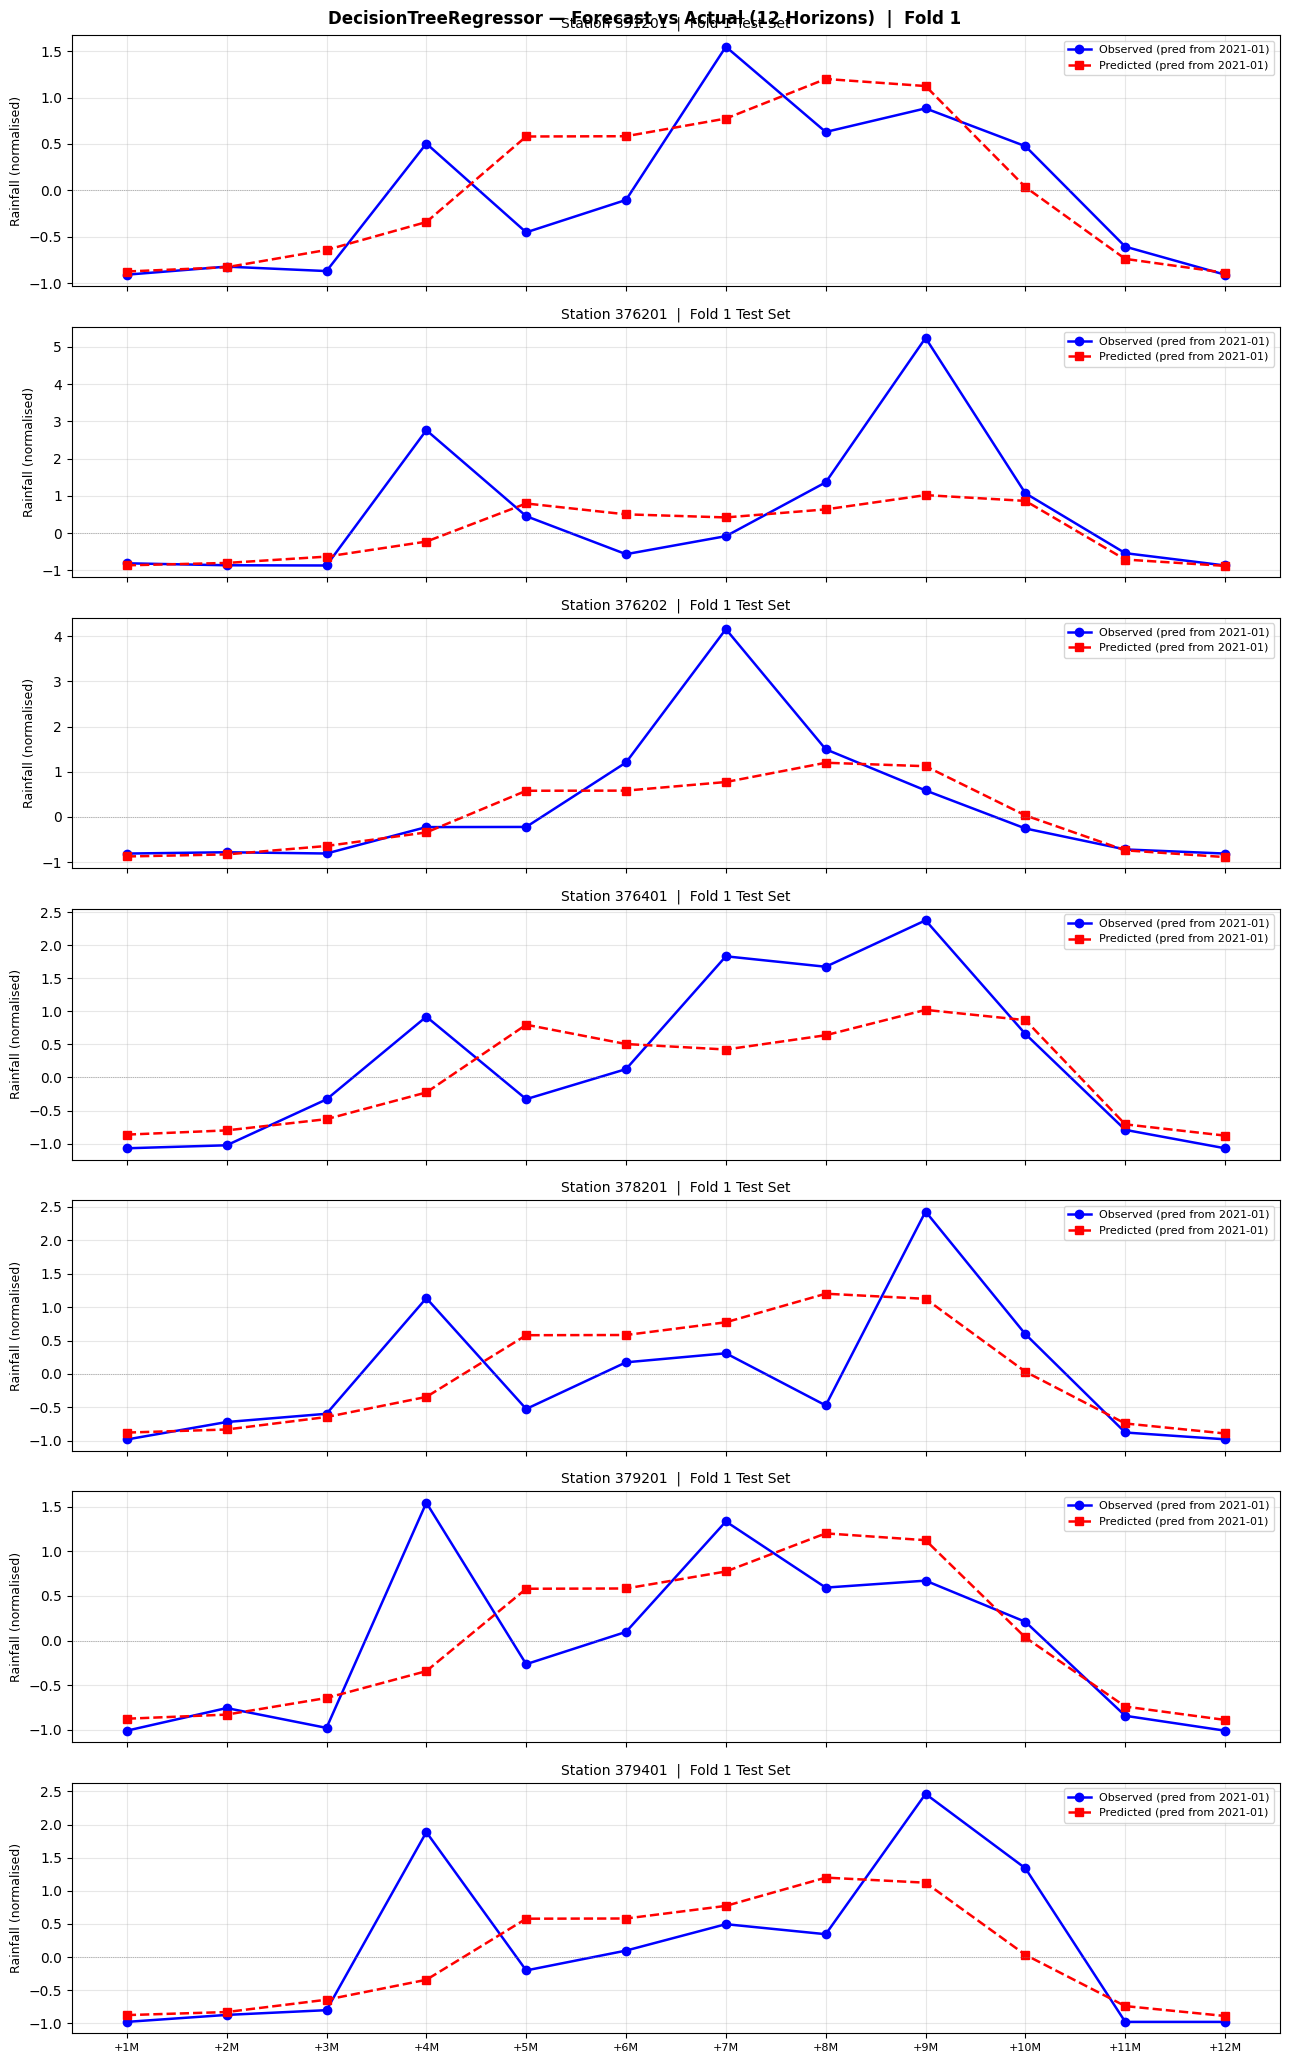

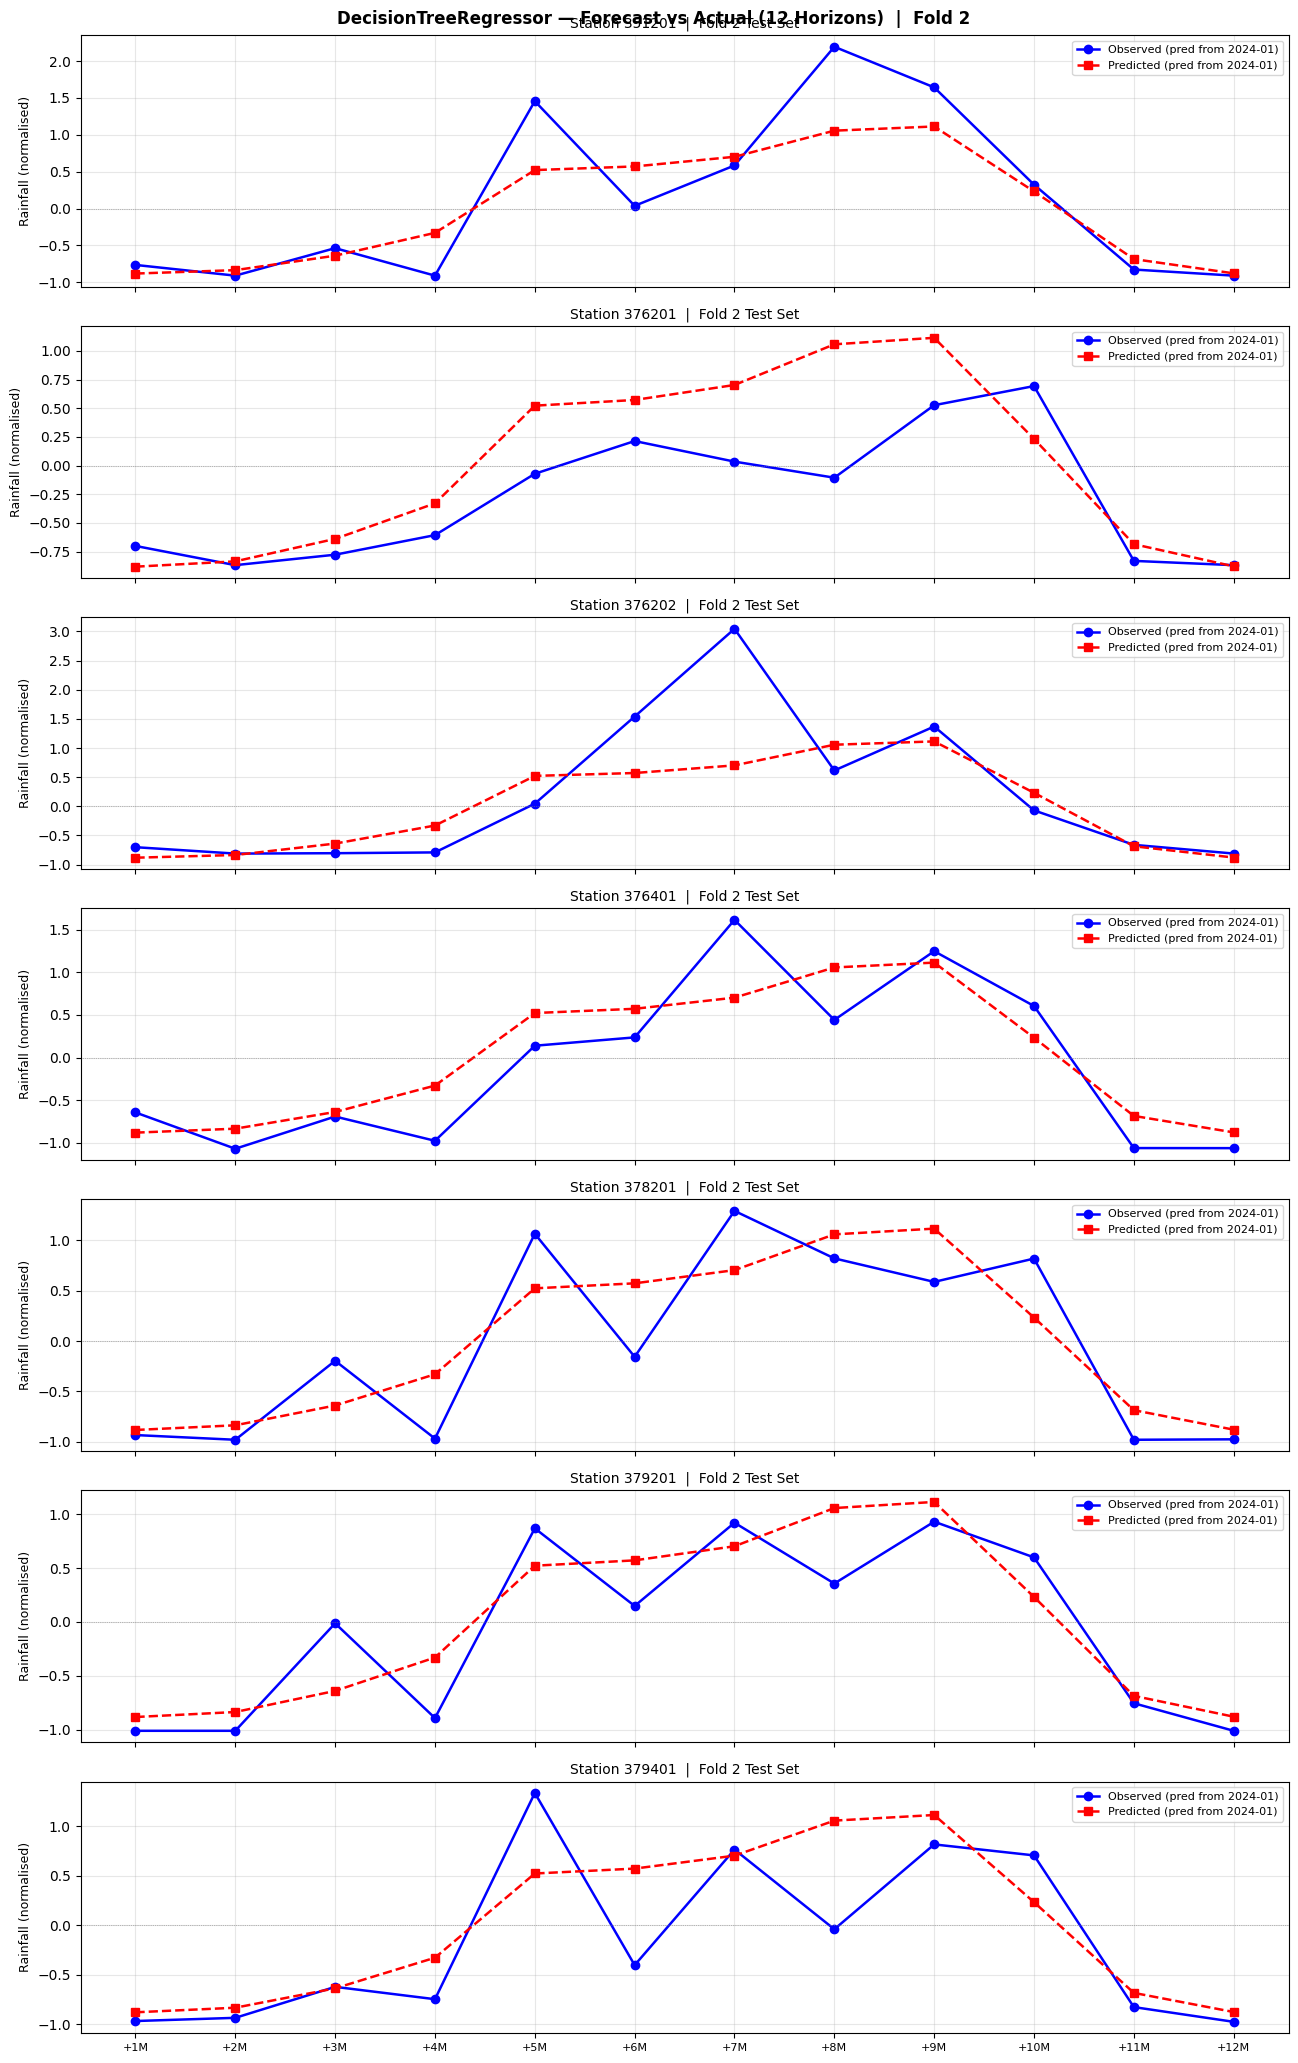

In [ ]:
for fold_idx in range(k_fold_num):
    y_te  = datasets[fold_idx]['y_test']
    y_pr  = datasets[fold_idx]['y_pred_test']
    d_te  = datasets[fold_idx]['dates_test']

    n_stations  = len(cluster_station)
    n_snapshots = y_te.shape[0] // n_stations
    x_ticks  = np.arange(1, horizon + 1)
    x_labels = [f'+{h+1}M' for h in range(horizon)]

    fig, axes = plt.subplots(n_stations, 1, figsize=(13, 3 * n_stations), sharex=True)
    if n_stations == 1:
        axes = [axes]

    for s_i, ax in enumerate(axes):
        for snap_j in range(n_snapshots):
            row_idx    = snap_j * n_stations + s_i
            obs        = y_te[row_idx]
            pred       = y_pr[row_idx]
            pred_start = pd.to_datetime(d_te[row_idx]).strftime('%Y-%m')
            lbl        = f' (pred from {pred_start})'

            if snap_j == 0:
                ax.plot(x_ticks, obs,  'b-o',  ms=6, lw=1.8, label=f'Observed{lbl}')
                ax.plot(x_ticks, pred, 'r--s', ms=6, lw=1.8, label=f'Predicted{lbl}')
            else:
                ax.plot(x_ticks, obs,  'b-o',  ms=4, lw=1.2, alpha=0.5)
                ax.plot(x_ticks, pred, 'r--s', ms=4, lw=1.2, alpha=0.5)

        ax.set_title(f'Station {station_codes[s_i]}  |  Fold {fold_idx+1} Test Set', fontsize=10)
        ax.set_ylabel('Rainfall (normalised)', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.axhline(0, color='gray', lw=0.5, ls=':')
        ax.grid(alpha=0.3)

    plt.suptitle(
        f'DecisionTreeRegressor — Forecast vs Actual ({horizon} Horizons)  |  Fold {fold_idx+1}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


## Cell 22 — Feature Importance (Top 20)

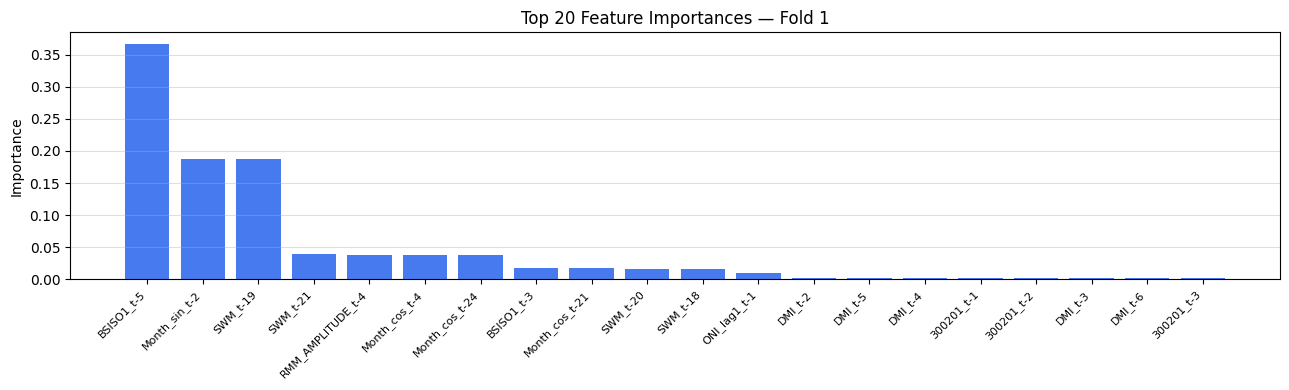

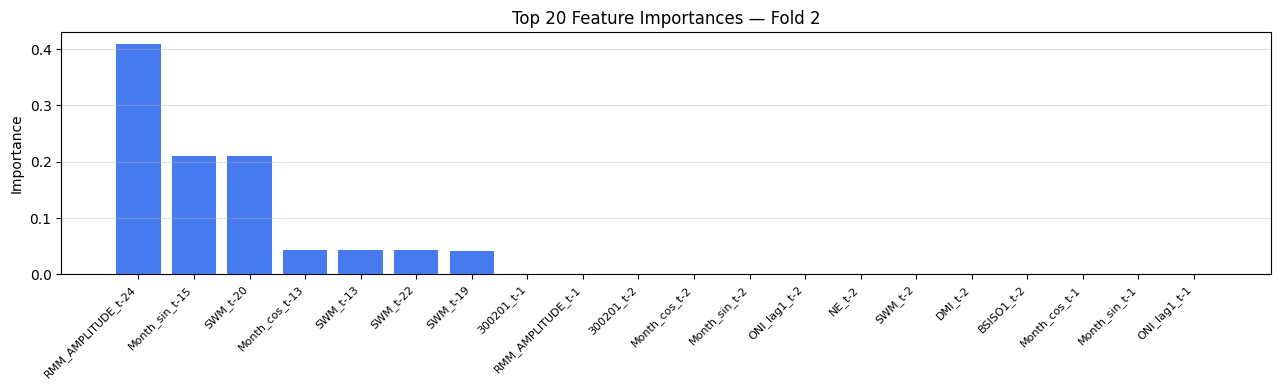

In [ ]:
col_names = list(fold[0][0][0].columns)   # 9 cols: 8 climate + 1 rainfall
feature_names = [
    f"{col}_t-{window_size - t}"
    for t in range(window_size)
    for col in col_names
]

for fold_idx in range(k_fold_num):
    importances = datasets[fold_idx]['model'].feature_importances_
    top_n   = 20
    top_idx = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(range(top_n), importances[top_idx], color='#2563EB', alpha=0.85)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(
        [feature_names[i] for i in top_idx],
        rotation=45, ha='right', fontsize=8
    )
    ax.set_title(f'Top {top_n} Feature Importances — Fold {fold_idx+1}', fontsize=12)
    ax.set_ylabel('Importance')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()


## Cell 23 — Per-Horizon Accuracy (Month +1 → +12)

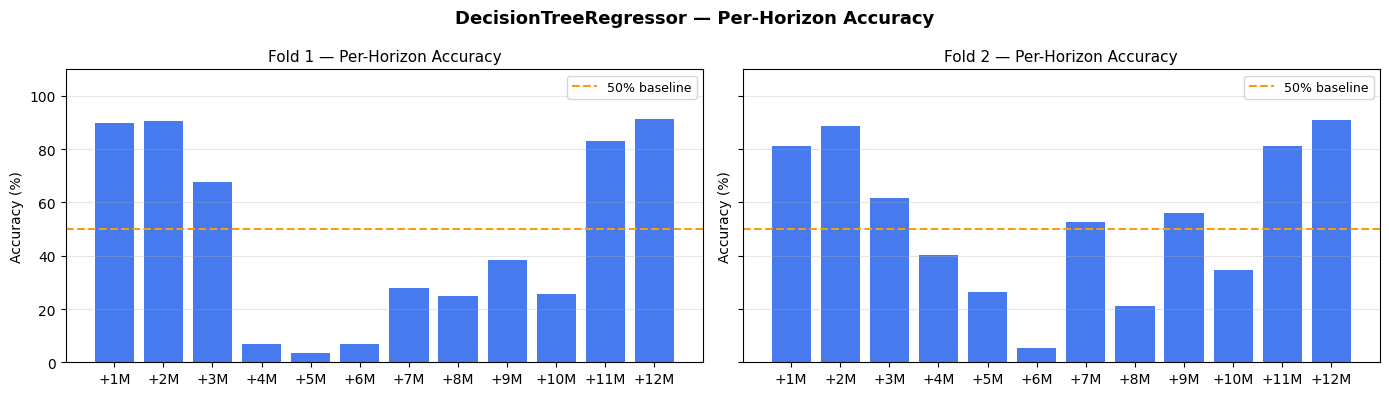

In [ ]:
fig, axes = plt.subplots(1, k_fold_num, figsize=(14, 4), sharey=True)
months_label = [f'+{m+1}M' for m in range(horizon)]

for fi in range(k_fold_num):
    acc_months = [
        results_df[results_df['fold_index'] == fi].iloc[0][f'acc_month{m+1}']
        for m in range(horizon)
    ]
    axes[fi].bar(months_label, acc_months, color='#2563EB', alpha=0.85)
    axes[fi].axhline(50, color='#F59E0B', lw=1.5, ls='--', label='50% baseline')
    axes[fi].set_title(f'Fold {fi+1} — Per-Horizon Accuracy', fontsize=11)
    axes[fi].set_ylabel('Accuracy (%)')
    axes[fi].set_ylim(0, 110)
    axes[fi].legend(fontsize=9)
    axes[fi].grid(axis='y', alpha=0.3)

plt.suptitle('DecisionTreeRegressor — Per-Horizon Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
